Hybrid Quantum GAN where only Generatorhave VQC embedded within classical NN,  and Discriminator is fully classical. Training on the MNIST dataset. I started with 4 qubits, then implemented 8 qubit. 


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import pennylane as qml
from pennylane.qnn import TorchLayer
import os
import torch.nn.functional as F
from torchvision.utils import make_grid, save_image
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
import matplotlib.pyplot as plt


Epoch  1 | D-loss: 0.3444 | G-loss: 1.3564
Epoch  2 | D-loss: 0.2594 | G-loss: 1.6696
Epoch  3 | D-loss: 0.2490 | G-loss: 1.8043
Epoch  4 | D-loss: 0.2664 | G-loss: 1.7484
Epoch  5 | D-loss: 0.2602 | G-loss: 1.7897
Epoch  6 | D-loss: 0.2516 | G-loss: 1.8305
Epoch  7 | D-loss: 0.2464 | G-loss: 1.8757
Epoch  8 | D-loss: 0.2422 | G-loss: 1.9158
Epoch  9 | D-loss: 0.2325 | G-loss: 1.9746
Epoch 10 | D-loss: 0.2255 | G-loss: 2.0231
Epoch 11 | D-loss: 0.2195 | G-loss: 2.0852
Epoch 12 | D-loss: 0.2169 | G-loss: 2.1203
Epoch 13 | D-loss: 0.2094 | G-loss: 2.1494
Epoch 14 | D-loss: 0.2053 | G-loss: 2.1985
Epoch 15 | D-loss: 0.2026 | G-loss: 2.2387
Epoch 16 | D-loss: 0.1984 | G-loss: 2.2515
Epoch 17 | D-loss: 0.1934 | G-loss: 2.3060
Epoch 18 | D-loss: 0.1918 | G-loss: 2.3075
Epoch 19 | D-loss: 0.1868 | G-loss: 2.3784
Epoch 20 | D-loss: 0.1855 | G-loss: 2.3768
Epoch 21 | D-loss: 0.1860 | G-loss: 2.4240
Epoch 22 | D-loss: 0.1796 | G-loss: 2.4366
Epoch 23 | D-loss: 0.1807 | G-loss: 2.4584
Epoch 24 | 

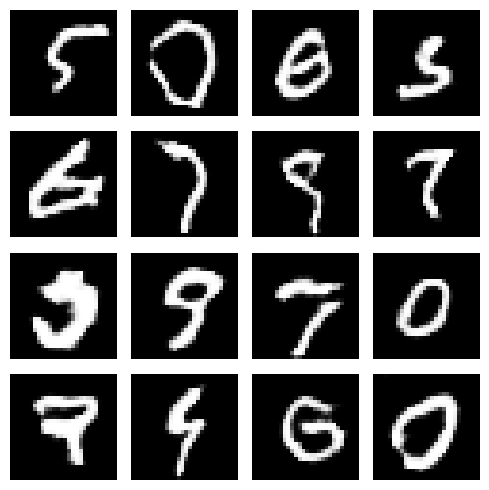

In [ ]:


batch_size = 128
latent_dim = 100
n_qubits   = 4
q_depth    = 3
lr         = 1e-4
n_epochs   = 30
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])
train_loader = DataLoader(
    datasets.MNIST(".", train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qcircuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]

weight_shapes = {"weights": (q_depth, n_qubits)}
quantum_layer = TorchLayer(qcircuit, weight_shapes).to(device)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.init_size = 7
        self.fc = nn.Linear(latent_dim, 128 * self.init_size**2)
        self.pre_q  = nn.Linear(128, n_qubits)
        self.post_q = nn.Linear(n_qubits, 128)
        self.upsample = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),            # 7→14
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2),            # 14→28
            nn.Conv2d(64, 1, 3, padding=1),
            nn.Tanh()                               # output in [−1,1]
        )

    def forward(self, z):
        b = z.size(0)
        x = self.fc(z).view(b, 128, self.init_size, self.init_size)
        feat = x.mean(dim=[2,3])                    # [b,128]
        angles = torch.tanh(self.pre_q(feat)) * torch.pi
        q_out = quantum_layer(angles)               # [b, n_qubits]
        fusion = self.post_q(q_out).view(b, 128, 1, 1)
        x = x * (1 + fusion)
        return self.upsample(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),   # 28→14
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1),  # 14→7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(64*7*7, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img)

G = Generator().to(device)
D = Discriminator().to(device)
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5,0.999))
criterion = nn.BCELoss()

for epoch in range(1, n_epochs+1):
    g_loss_acc = 0.0
    d_loss_acc = 0.0
    for real_imgs, _ in train_loader:
        real = real_imgs.to(device)
        b = real.size(0)
        ones  = torch.ones(b,1, device=device)
        zeros = torch.zeros(b,1, device=device)

        opt_D.zero_grad()
        d_real = D(real)
        loss_real = criterion(d_real, ones)
        z = torch.randn(b, latent_dim, device=device)
        fake = G(z).detach()
        d_fake = D(fake)
        loss_fake = criterion(d_fake, zeros)
        d_loss = (loss_real + loss_fake) * 0.5
        d_loss.backward()
        opt_D.step()

        opt_G.zero_grad()
        z = torch.randn(b, latent_dim, device=device)
        gen = G(z)
        g_loss = criterion(D(gen), ones)
        g_loss.backward()
        opt_G.step()

        d_loss_acc += d_loss.item()
        g_loss_acc += g_loss.item()

    print(f"Epoch {epoch:2d} | D-loss: {d_loss_acc/len(train_loader):.4f} | "
          f"G-loss: {g_loss_acc/len(train_loader):.4f}")

G.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim, device=device)
    samples = G(z).cpu().squeeze().numpy()

fig, axs = plt.subplots(4,4, figsize=(5,5))
for ax, img in zip(axs.flatten(), samples):
    ax.imshow(img, cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")
plt.tight_layout()
plt.show()


Training MNIST classifier for mode-collapse…
  Epoch 1/3  acc = 0.9298
  Epoch 2/3  acc = 0.9815
  Epoch 3/3  acc = 0.9864
Classifier ready.

FID:                69.97


c:\Users\maya\gsoc\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Inception Score:    1.08 ± 0.03
Mode Collapse Rate: 0.0%
PSNR:               8.58
SSIM:               0.191


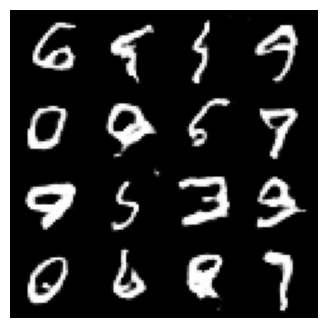

In [3]:

cla_batch = 64
cla_transform = transforms.ToTensor()  # [0,1]
cla_train_loader = DataLoader(
    datasets.MNIST("./data", train=True, download=True, transform=cla_transform),
    batch_size=cla_batch, shuffle=True
)

class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),  # 28×28 → 28×28
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 14×14
            nn.Conv2d(32, 64, 3, 1, 1), # → 14×14
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 7×7
            nn.Flatten(),               # → 64*7*7
            nn.Linear(64*7*7, 128),
            nn.ReLU(True),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

classifier = MNISTClassifier().to(device)
opt_C = optim.Adam(classifier.parameters(), lr=1e-3)
criterion_C = nn.CrossEntropyLoss()

for epoch in range(3):
    classifier.train()
    total, correct = 0, 0
    for imgs, labels in cla_train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = classifier(imgs)
        loss = criterion_C(logits, labels)
        opt_C.zero_grad(); loss.backward(); opt_C.step()

        preds = logits.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    acc = correct / total
    print(f"Classifier Epoch {epoch+1}/3 – Accuracy: {acc:.4f}")


def compute_fid(real_imgs: torch.Tensor, fake_imgs: torch.Tensor, device=device) -> float:
    real_uint8 = (real_imgs * 255).to(torch.uint8)
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    fid = FrechetInceptionDistance(feature=2048).to(device)
    fid.update(real_uint8, real=True)
    fid.update(fake_uint8, real=False)
    return fid.compute().item()

def compute_inception_score(fake_imgs: torch.Tensor, device=device):
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    is_metric = InceptionScore(feature=2048).to(device)
    is_metric.update(fake_uint8)
    mean, std = is_metric.compute()
    return mean.item(), std.item()

def compute_mode_collapse(model, classifier, n_images=10000, device=device) -> float:
    model.eval(); classifier.eval()
    with torch.no_grad():
        z = torch.randn(n_images, latent_dim, device=device)
        fake = (model(z) + 1) / 2.0
        preds = classifier(fake).argmax(dim=1).cpu().tolist()
    seen = len(set(preds))
    return (1 - seen / 10.0) * 100 

def compute_psnr_ssim(real_images: torch.Tensor, fake_images: torch.Tensor):
    real_np = real_images.cpu().numpy()
    fake_np = fake_images.cpu().numpy()
    psnr_vals, ssim_vals = [], []
    for r, f in zip(real_np, fake_np):
        r2, f2 = r.squeeze(), f.squeeze()
        psnr_vals.append(psnr(r2, f2, data_range=1.0))
        ssim_vals.append(ssim(r2, f2, data_range=1.0))
    return sum(psnr_vals)/len(psnr_vals), sum(ssim_vals)/len(ssim_vals)


G.eval()

real_batch, _ = next(iter(train_loader))
real_small = (real_batch.to(device) + 1) / 2            # [0,1], [B,1,28,28]
real_for_fid = real_small.repeat(1,3,1,1)               # [B,3,28,28]
real_for_fid = F.interpolate(real_for_fid, size=(299,299), mode='bilinear')

with torch.no_grad():
    z = torch.randn(real_for_fid.size(0), latent_dim, device=device)
    fake_small = G(z).cpu().clamp(-1,1).add(1).div(2)   # [0,1], [B,1,28,28]
fake_for_fid = fake_small.repeat(1,3,1,1)
fake_for_fid = F.interpolate(fake_for_fid, size=(299,299), mode='bilinear')

fid_val = compute_fid(real_for_fid, fake_for_fid, device)
print(f"FID:                 {fid_val:.2f}")

is_mean, is_std = compute_inception_score(fake_for_fid, device)
print(f"Inception Score:     {is_mean:.2f} ± {is_std:.2f}")

mode_rate = compute_mode_collapse(G, classifier, device=device)
print(f"Mode Collapse Rate:  {mode_rate:.1f}%")

psnr_val, ssim_val = compute_psnr_ssim(real_small.cpu(), fake_small)
print(f"PSNR:                {psnr_val:.2f}")
print(f"SSIM:                {ssim_val:.3f}")

with torch.no_grad():
    z2 = torch.randn(16, latent_dim, device=device)
    samples = (G(z2).cpu().clamp(-1,1).add(1).div(2))   # [0,1], [16,1,28,28]
grid = make_grid(samples, nrow=4)
plt.figure(figsize=(4,4))
plt.imshow(grid.permute(1,2,0).squeeze(), cmap='gray')
plt.axis('off')
plt.show()


Now, use 8 qubits and encode 16 angles through RX and RY. 

Epoch  1 | D-loss: 0.3809 | G-loss: 1.2346
Epoch  2 | D-loss: 0.3133 | G-loss: 1.4539
Epoch  3 | D-loss: 0.2959 | G-loss: 1.5841
Epoch  4 | D-loss: 0.3001 | G-loss: 1.5878
Epoch  5 | D-loss: 0.2985 | G-loss: 1.6180
Epoch  6 | D-loss: 0.2930 | G-loss: 1.6342
Epoch  7 | D-loss: 0.2863 | G-loss: 1.6821
Epoch  8 | D-loss: 0.2799 | G-loss: 1.7164
Epoch  9 | D-loss: 0.2737 | G-loss: 1.7715
Epoch 10 | D-loss: 0.2672 | G-loss: 1.8165
Epoch 11 | D-loss: 0.2625 | G-loss: 1.8595
Epoch 12 | D-loss: 0.2586 | G-loss: 1.8848
Epoch 13 | D-loss: 0.2561 | G-loss: 1.9351
Epoch 14 | D-loss: 0.2490 | G-loss: 1.9440
Epoch 15 | D-loss: 0.2473 | G-loss: 1.9860
Epoch 16 | D-loss: 0.2407 | G-loss: 2.0136
Epoch 17 | D-loss: 0.2381 | G-loss: 2.0426
Epoch 18 | D-loss: 0.2340 | G-loss: 2.0776
Epoch 19 | D-loss: 0.2321 | G-loss: 2.0938
Epoch 20 | D-loss: 0.2316 | G-loss: 2.1224
Epoch 21 | D-loss: 0.2270 | G-loss: 2.1348
Epoch 22 | D-loss: 0.2260 | G-loss: 2.1555
Epoch 23 | D-loss: 0.2246 | G-loss: 2.1786
Epoch 24 | 

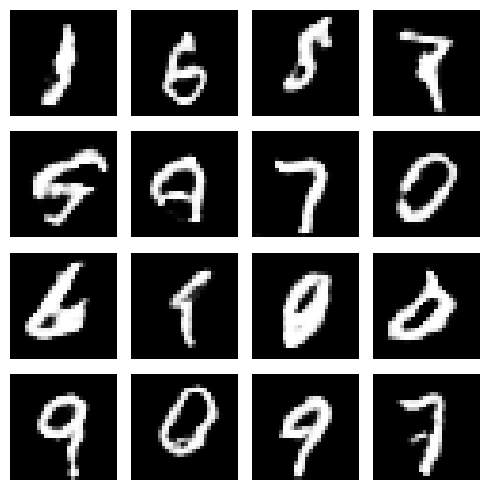

In [ ]:
batch_size = 128
latent_dim = 100
n_qubits   = 8           
q_depth    = 3
lr         = 1e-4
n_epochs   = 30
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])
train_loader = DataLoader(
    datasets.MNIST(".", train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)


dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qcircuit(inputs, weights):
    for i in range(n_qubits):
        qml.RX(inputs[..., i], wires=i)
        qml.RY(inputs[..., i + n_qubits], wires=i)
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]

weight_shapes = {"weights": (q_depth, n_qubits)}
quantum_layer = TorchLayer(qcircuit, weight_shapes).to(device)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.init_size = 7
        self.fc = nn.Linear(latent_dim, 128 * self.init_size**2)
        self.pre_q  = nn.Linear(128, 2 * n_qubits)
        self.post_q = nn.Linear(n_qubits, 128)
        self.upsample = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),            # 7→14
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2),            # 14→28
            nn.Conv2d(64, 1, 3, padding=1),
            nn.Tanh()                               # output in [−1,1]
        )

    def forward(self, z):
        b = z.size(0)
        x = self.fc(z).view(b, 128, self.init_size, self.init_size)
        feat   = x.mean(dim=[2,3])                       # [b,128]
        angles = torch.tanh(self.pre_q(feat)) * torch.pi # [b, 16]
        q_out  = quantum_layer(angles)                   # [b, 8]
        fusion = self.post_q(q_out).view(b, 128, 1, 1)
        x = x * (1 + fusion)
        return self.upsample(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),   # 28→14
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1),  # 14→7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(64*7*7, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img)

G = Generator().to(device)
D = Discriminator().to(device)
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5,0.999))
criterion = nn.BCELoss()

for epoch in range(1, n_epochs+1):
    g_loss_acc = 0.0
    d_loss_acc = 0.0
    for real_imgs, _ in train_loader:
        real = real_imgs.to(device)
        b = real.size(0)
        ones  = torch.ones(b,1, device=device)
        zeros = torch.zeros(b,1, device=device)

        opt_D.zero_grad()
        loss_real = criterion(D(real), ones)
        z = torch.randn(b, latent_dim, device=device)
        fake = G(z).detach()
        loss_fake = criterion(D(fake), zeros)
        d_loss = 0.5 * (loss_real + loss_fake)
        d_loss.backward()
        opt_D.step()

        opt_G.zero_grad()
        z = torch.randn(b, latent_dim, device=device)
        gen = G(z)
        g_loss = criterion(D(gen), ones)
        g_loss.backward()
        opt_G.step()

        d_loss_acc += d_loss.item()
        g_loss_acc += g_loss.item()

    print(f"Epoch {epoch:2d} | D-loss: {d_loss_acc/len(train_loader):.4f} | "
          f"G-loss: {g_loss_acc/len(train_loader):.4f}")

G.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim, device=device)
    samples = G(z).cpu().squeeze().numpy()

fig, axs = plt.subplots(4,4, figsize=(5,5))
for ax, img in zip(axs.flatten(), samples):
    ax.imshow(img, cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")
plt.tight_layout()
plt.show()


Training MNIST classifier for mode-collapse…
  Epoch 1/3  acc = 0.9311
  Epoch 2/3  acc = 0.9822
  Epoch 3/3  acc = 0.9874
Classifier ready.

FID:                69.37
Inception Score:    1.08 ± 0.03
Mode Collapse Rate: 0.0%
PSNR:               8.77
SSIM:               0.203


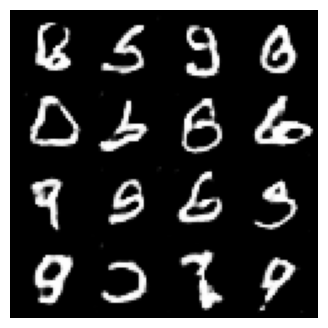

In [ ]:

cla_batch = 64
cla_transform = transforms.ToTensor()  # [0,1]
cla_train_loader = DataLoader(
    datasets.MNIST("./data", train=True, download=True, transform=cla_transform),
    batch_size=cla_batch, shuffle=True
)

class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),  # 28×28 → 28×28
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 14×14
            nn.Conv2d(32, 64, 3, 1, 1), # → 14×14
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 7×7
            nn.Flatten(),               # → 64*7*7
            nn.Linear(64*7*7, 128),
            nn.ReLU(True),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

classifier = MNISTClassifier().to(device)
opt_C = optim.Adam(classifier.parameters(), lr=1e-3)
criterion_C = nn.CrossEntropyLoss()

for epoch in range(3):
    classifier.train()
    total, correct = 0, 0
    for imgs, labels in cla_train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = classifier(imgs)
        loss = criterion_C(logits, labels)
        opt_C.zero_grad(); loss.backward(); opt_C.step()

        preds = logits.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    acc = correct / total
    print(f"Classifier Epoch {epoch+1}/3 – Accuracy: {acc:.4f}")


def compute_fid(real_imgs: torch.Tensor, fake_imgs: torch.Tensor, device=device) -> float:
    real_uint8 = (real_imgs * 255).to(torch.uint8)
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    fid = FrechetInceptionDistance(feature=2048).to(device)
    fid.update(real_uint8, real=True)
    fid.update(fake_uint8, real=False)
    return fid.compute().item()

def compute_inception_score(fake_imgs: torch.Tensor, device=device):
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    is_metric = InceptionScore(feature=2048).to(device)
    is_metric.update(fake_uint8)
    mean, std = is_metric.compute()
    return mean.item(), std.item()

def compute_mode_collapse(model, classifier, n_images=10000, device=device) -> float:
    model.eval(); classifier.eval()
    with torch.no_grad():
        z = torch.randn(n_images, latent_dim, device=device)
        fake = (model(z) + 1) / 2.0
        preds = classifier(fake).argmax(dim=1).cpu().tolist()
    seen = len(set(preds))
    return (1 - seen / 10.0) * 100 

def compute_psnr_ssim(real_images: torch.Tensor, fake_images: torch.Tensor):
    real_np = real_images.cpu().numpy()
    fake_np = fake_images.cpu().numpy()
    psnr_vals, ssim_vals = [], []
    for r, f in zip(real_np, fake_np):
        r2, f2 = r.squeeze(), f.squeeze()
        psnr_vals.append(psnr(r2, f2, data_range=1.0))
        ssim_vals.append(ssim(r2, f2, data_range=1.0))
    return sum(psnr_vals)/len(psnr_vals), sum(ssim_vals)/len(ssim_vals)


G.eval()

real_batch, _ = next(iter(train_loader))
real_small = (real_batch.to(device) + 1) / 2            # [0,1], [B,1,28,28]
real_for_fid = real_small.repeat(1,3,1,1)               # [B,3,28,28]
real_for_fid = F.interpolate(real_for_fid, size=(299,299), mode='bilinear')

with torch.no_grad():
    z = torch.randn(real_for_fid.size(0), latent_dim, device=device)
    fake_small = G(z).cpu().clamp(-1,1).add(1).div(2)   # [0,1], [B,1,28,28]
fake_for_fid = fake_small.repeat(1,3,1,1)
fake_for_fid = F.interpolate(fake_for_fid, size=(299,299), mode='bilinear')

fid_val = compute_fid(real_for_fid, fake_for_fid, device)
print(f"FID:                 {fid_val:.2f}")

is_mean, is_std = compute_inception_score(fake_for_fid, device)
print(f"Inception Score:     {is_mean:.2f} ± {is_std:.2f}")

mode_rate = compute_mode_collapse(G, classifier, device=device)
print(f"Mode Collapse Rate:  {mode_rate:.1f}%")

psnr_val, ssim_val = compute_psnr_ssim(real_small.cpu(), fake_small)
print(f"PSNR:                {psnr_val:.2f}")
print(f"SSIM:                {ssim_val:.3f}")

with torch.no_grad():
    z2 = torch.randn(16, latent_dim, device=device)
    samples = (G(z2).cpu().clamp(-1,1).add(1).div(2))   # [0,1], [16,1,28,28]
grid = make_grid(samples, nrow=4)
plt.figure(figsize=(4,4))
plt.imshow(grid.permute(1,2,0).squeeze(), cmap='gray')
plt.axis('off')
plt.show()


Then, the same exact GAN was tested with 10 epochs of training, the result was much worse. 